# 📊 Exploratory Data Analysis (EDA) — Heart Disease Dataset

This notebook explores a heart disease dataset to understand the underlying patterns in patient
demographics, clinical measurements, symptoms, and their relationship with the target variable
(`HeartDisease`). The analysis is organized into four main sections:

1. **Demographics** — age and gender distribution
2. **Clinical Measurements** — resting blood pressure, cholesterol, heart rate ratio, and fasting blood sugar
3. **Symptoms** — chest pain type, exercise-induced angina, oldpeak, and ST slope
4. **Target & Correlation** — class balance and feature correlation

For categorical comparisons that would normally use interactive filters (e.g. by gender or diagnosis
status), each condition is shown sequentially as separate plots so that every insight is captured
without requiring interactive widgets.

## 1. Import Library

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 2. Load Dataset



In [28]:
df = pd.read_csv("../Data/heart.csv")  # replace with your dataset path
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 3. Data Quality & Anomaly Detection

This section covers:
- **Missing values** — checking for null data
- **Duplicate rows** — identifying redundant entries
- **Data types** — confirming each column has the correct type
- **Descriptive statistics** — overview of numerical feature distributions
- **Categorical value counts** — checking unique values in categorical columns
- **Anomaly detection** — flagging suspicious values like zero cholesterol or blood pressure

In [29]:
# 1. Missing Values
print("=" * 60)
print("1. MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Percentage (%)": missing_pct.round(2)})
print(missing_df[missing_df["Missing Count"] > 0] if missing.sum() > 0 else "✅ No missing values found!\n")

# 2. Duplicate Rows
print("=" * 60)
print("2. DUPLICATE ROWS")
print("=" * 60)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
if duplicates > 0:
    print("Duplicate rows (first 5):")
    print(df[df.duplicated(keep=False)].sort_index().head(10))
print()

# 3. Data Types & Shape
print("=" * 60)
print("3. DATA TYPES & SHAPE")
print("=" * 60)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
dtype_df = pd.DataFrame({
    "Column": df.dtypes.index,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.count().values,
    "Unique Values": [df[c].nunique() for c in df.columns]
})
print(dtype_df.to_string(index=False))
print()

# 4. Descriptive Statistics for Numerical Features
print("=" * 60)
print("4. DESCRIPTIVE STATISTICS (Numerical Features)")
print("=" * 60)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(df[num_cols].describe().round(2))
print()

# 5. Categorical Columns — Value Counts
print("=" * 60)
print("5. CATEGORICAL COLUMNS — UNIQUE VALUES")
print("=" * 60)
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    print(f"\n>>> {col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().to_string())
print()

# 6. Anomaly Detection
print("=" * 60)
print("6. ANOMALY DETECTION")
print("=" * 60)

# Cholesterol = 0 anomaly
zero_chol = df[df["Cholesterol"] == 0].shape[0]
print(f"🔸 Cholesterol = 0 (suspicious): {zero_chol} rows ({zero_chol/len(df)*100:.2f}%)")

# RestingBP = 0 anomaly
zero_bp = df[df["RestingBP"] == 0].shape[0]
print(f"🔸 RestingBP = 0 (suspicious): {zero_bp} rows ({zero_bp/len(df)*100:.2f}%)")

# RestingBP > 220 (extreme hypertension)
high_bp = df[df["RestingBP"] > 220].shape[0]
print(f"🔸 RestingBP > 220 mmHg (extreme): {high_bp} rows ({high_bp/len(df)*100:.2f}%)")

# Cholesterol > 500 (extremely high)
high_chol = df[df["Cholesterol"] > 500].shape[0]
print(f"🔸 Cholesterol > 500 mg/dl (extreme): {high_chol} rows ({high_chol/len(df)*100:.2f}%)")

# MaxHR outside plausible range (60–220)
unlikely_hr = df[(df["MaxHR"] < 60) | (df["MaxHR"] > 220)].shape[0]
print(f"🔸 MaxHR < 60 or > 220 (unlikely): {unlikely_hr} rows ({unlikely_hr/len(df)*100:.2f}%)")

# Oldpeak negative values (typically ST depression is ≥ 0)
neg_oldpeak = df[df["Oldpeak"] < 0].shape[0]
print(f"🔸 Oldpeak < 0 (unusual): {neg_oldpeak} rows ({neg_oldpeak/len(df)*100:.2f}%)")

1. MISSING VALUES
✅ No missing values found!

2. DUPLICATE ROWS
Total duplicate rows: 0

3. DATA TYPES & SHAPE
Dataset shape: 918 rows × 12 columns

        Column Data Type  Non-Null Count  Unique Values
           Age     int64             918             50
           Sex    object             918              2
 ChestPainType    object             918              4
     RestingBP     int64             918             67
   Cholesterol     int64             918            222
     FastingBS     int64             918              2
    RestingECG    object             918              3
         MaxHR     int64             918            119
ExerciseAngina    object             918              2
       Oldpeak   float64             918             53
      ST_Slope    object             918              3
  HeartDisease     int64             918              2

4. DESCRIPTIVE STATISTICS (Numerical Features)
          Age  RestingBP  Cholesterol  FastingBS   MaxHR  Oldpeak  \
count 

**Insight — Data Quality:** The dataset has no missing values or duplicate rows, so no imputation or
deduplication is needed. However, several anomalies were found: some patients have **Cholesterol = 0** or
**RestingBP = 0**, which are biologically impossible and likely represent missing or erroneously recorded values.
Additionally, a few patients have **RestingBP > 220 mmHg** or **Cholesterol > 500 mg/dl** — these extreme
values, while possible in severe cases, warrant careful handling during preprocessing to avoid biasing the model.


### Feature Engineering: `HR_Ratio`

`HR_Ratio` is calculated as `MaxHR` normalized by age (`MaxHR / (220 - Age)`). The variable `df_r`
is used for the Age vs MaxHR scatter plot.

In [30]:
df["HR_Ratio"] = df["MaxHR"] / (220 - df["Age"])

# df_r is the dataframe used for the Age vs MaxHR scatter plot
df_r = df.copy()

df[["Age", "MaxHR", "HR_Ratio"]].head()

,Age,MaxHR,HR_Ratio
0,40,172,0.955556
1,49,156,0.912281
2,37,98,0.535519
3,48,108,0.627907
4,54,122,0.734940


---
## 1. Demographics

### Age Distribution Among the Patients

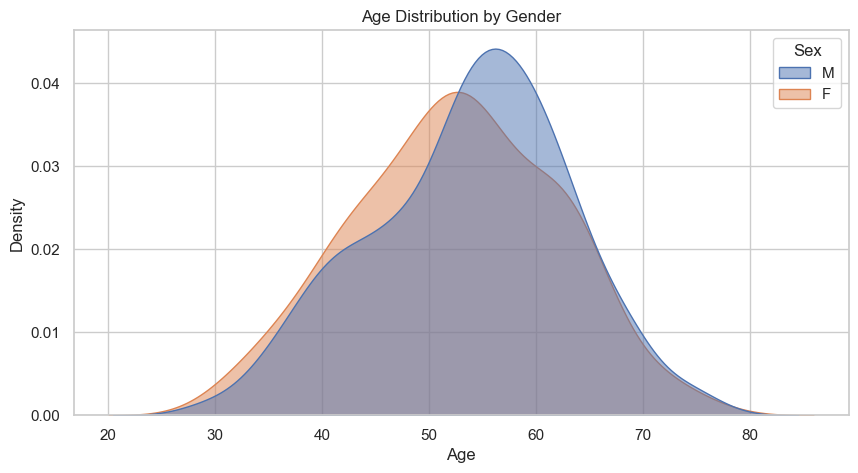

In [31]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Age', hue='Sex', fill=True, common_norm=False, alpha=0.5)
plt.title('Age Distribution by Gender')
plt.show()

**Insight — Age Distribution by Gender (KDE Plot):** The KDE plot overlays the age distribution of male
and female patients, making it easy to compare their age profiles. Both genders show a similar middle-aged
peak, with the highest density around ages 50–60. However, male patients have a slightly broader spread
with a more pronounced peak in the mid-50s, while female patients show a somewhat wider distribution that
extends further into older ages. This comparison suggests that although both men and women in the dataset
are predominantly middle-aged, heart disease risk spans a broader age range for women.

### Gender Distribution

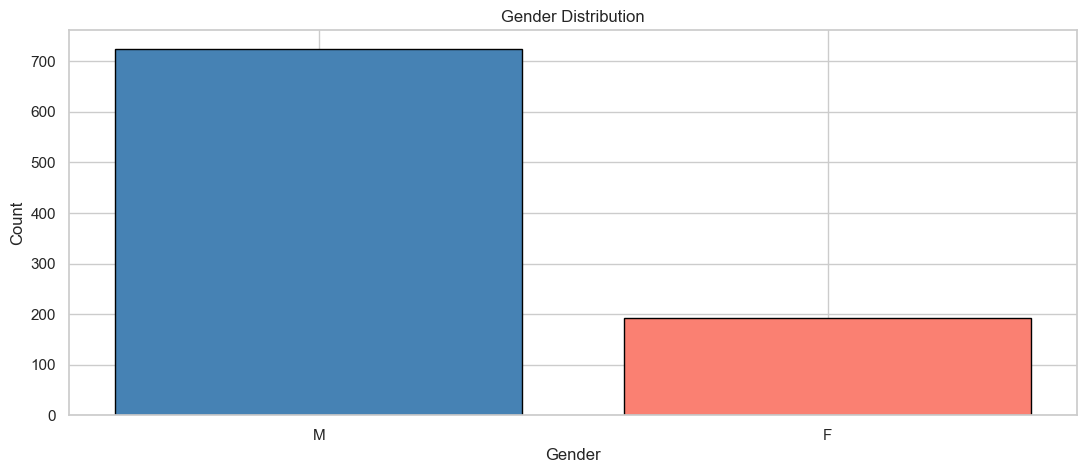

In [32]:
filtered_df_gender = df 

gender_counts = filtered_df_gender["Sex"].value_counts()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(gender_counts.index, gender_counts.values, color=["steelblue", "salmon"], edgecolor="black")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
ax.set_title(f"Gender Distribution")
plt.show()

c:\Users\NOUFAL PELLU\Documents\PROJEK-PROJEK\PROJEKISENG\HEARTDISEASE\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128153 (\N{BLUE HEART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


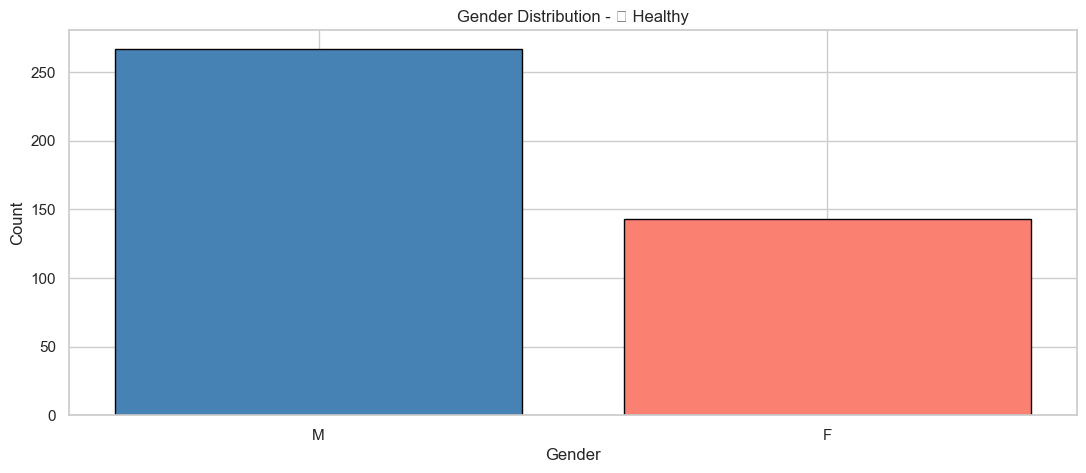

In [33]:
filtered_df_gender = df[df["HeartDisease"] == 0]  # 💙 Healthy

gender_counts = filtered_df_gender["Sex"].value_counts()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(gender_counts.index, gender_counts.values, color=["steelblue", "salmon"], edgecolor="black")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
ax.set_title(f"Gender Distribution - 💙 Healthy")
plt.show()

c:\Users\NOUFAL PELLU\Documents\PROJEK-PROJEK\PROJEKISENG\HEARTDISEASE\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10084 (\N{HEAVY BLACK HEART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\NOUFAL PELLU\Documents\PROJEK-PROJEK\PROJEKISENG\HEARTDISEASE\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


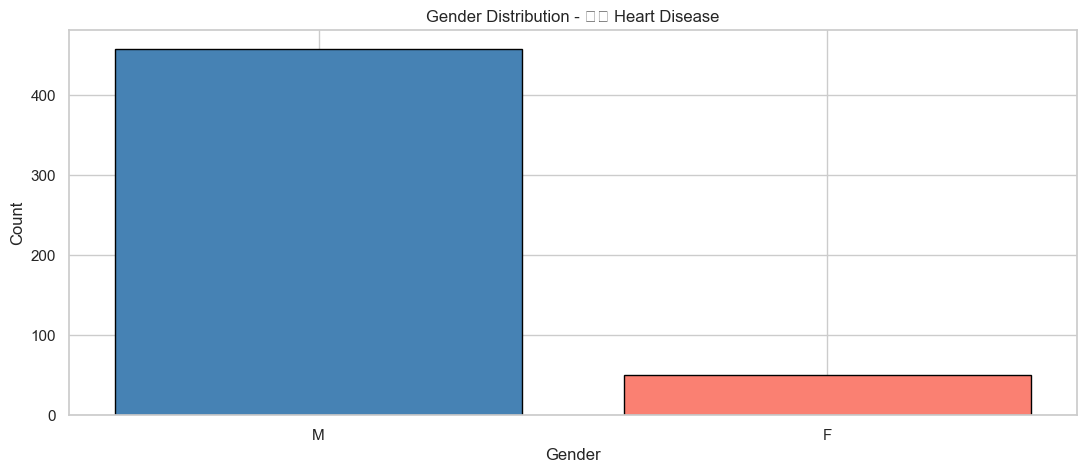

In [34]:
filtered_df_gender = df[df["HeartDisease"] == 1]  # ❤️ Heart Disease

gender_counts = filtered_df_gender["Sex"].value_counts()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(gender_counts.index, gender_counts.values, color=["steelblue", "salmon"], edgecolor="black")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
ax.set_title(f"Gender Distribution - ❤️ Heart Disease")
plt.show()

**Insight — All:** This chart shows that most of the patients in our dataset are men, while women make up
a smaller portion. The difference is quite noticeable, with men outnumbering women by a wide margin. In simple
terms, this tells us that heart disease in this dataset appears more frequently among men, highlighting how
gender can play an important role in understanding health risks.

**Insight — Healthy:** Looking only at healthy individuals, men slightly outnumber women. This means that in
the dataset, there are more men without heart disease than women, though the difference is not as dramatic as
in the overall population.

**Insight — Heart Disease:** When focusing on patients diagnosed with heart disease, the difference between
genders becomes striking. Men make up the vast majority of cases, while women represent only a small
fraction. This emphasizes how much more common heart disease appears among men in this dataset.

---
## 2. Clinical Measurements

### Resting Blood Pressure

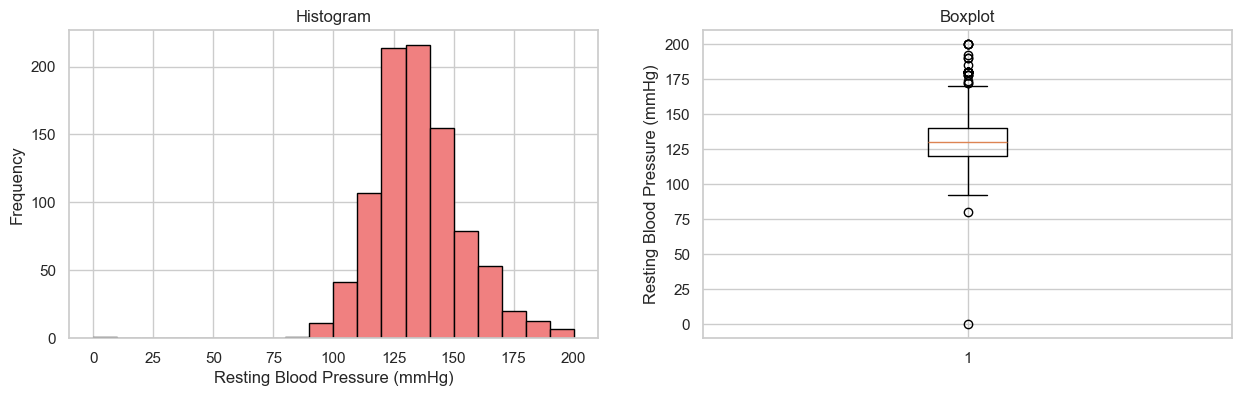

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].hist(df["RestingBP"], bins=20, color="lightcoral", edgecolor="black")
ax[0].set_xlabel("Resting Blood Pressure (mmHg)")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Histogram")

ax[1].boxplot(df["RestingBP"], vert=True)
ax[1].set_ylabel("Resting Blood Pressure (mmHg)")
ax[1].set_title("Boxplot")
plt.show()

**Insight:** Most patients have resting blood pressure around 130–140 mmHg, which is slightly above the
normal range. The histogram shows this cluster clearly. The boxplot adds another layer — it highlights the
median near 135 mmHg and reveals several outliers above 180 mmHg. These outliers tell us that while many
patients fall into a moderately elevated range, a smaller group experiences very high blood pressure, pointing
to more severe hypertension risks.

### Cholesterol

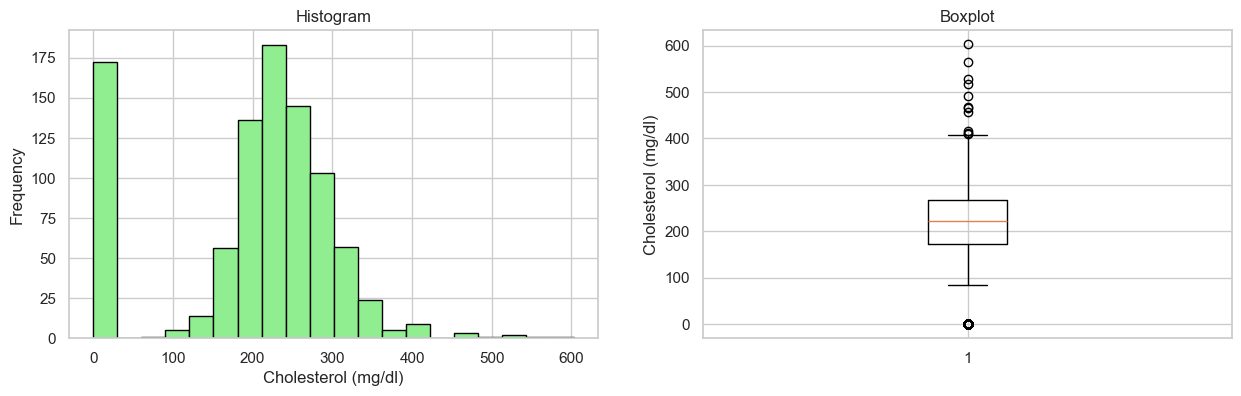

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].hist(df["Cholesterol"], bins=20, color="lightgreen", edgecolor="black")
ax[0].set_xlabel("Cholesterol (mg/dl)")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Histogram")

ax[1].boxplot(df["Cholesterol"], vert=True)
ax[1].set_ylabel("Cholesterol (mg/dl)")
ax[1].set_title("Boxplot")
plt.show()

**Insight:** The histogram shows that most patients have cholesterol levels clustered around 250–300
mg/dl, which is higher than the recommended healthy range. Then the boxplot explains that the median sits near
250 mg/dl, but there are many outliers above 400 mg/dl. These extreme values highlight that while elevated
cholesterol is common, a smaller group of patients face dangerously high levels that could significantly
increase cardiovascular risk. Together, the two charts tell us that cholesterol problems are widespread, and
for some individuals, they are severe.

### Heart Rate Ratio Distribution

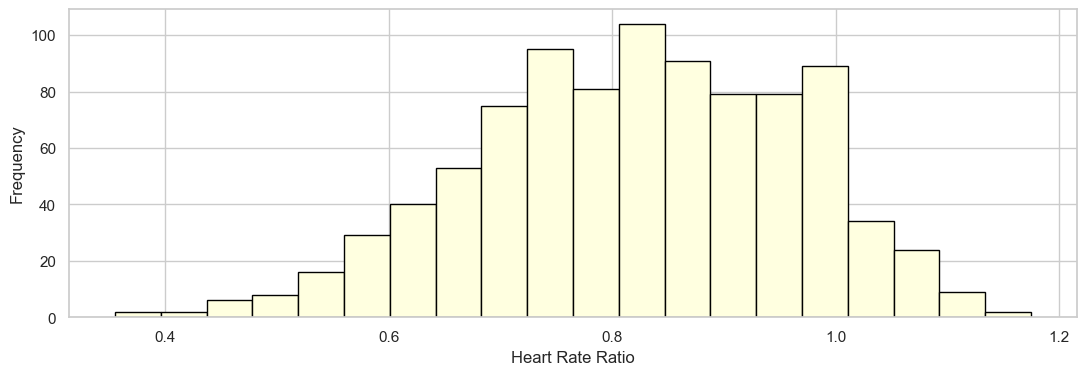

In [37]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.hist(df["HR_Ratio"], bins=20, color="lightyellow", edgecolor="black")
ax.set_xlabel("Heart Rate Ratio")
ax.set_ylabel("Frequency")
plt.show()

**Insight:** The heart rate ratio represents MaxHR normalized by age (`MaxHR / (220 - Age)`). This shows
the relative exercise capacity adjusted for age. Values closer to 1.0 indicate better cardiovascular fitness
relative to age expectations.

### Scatter Plot: Age vs Max Heart Rate

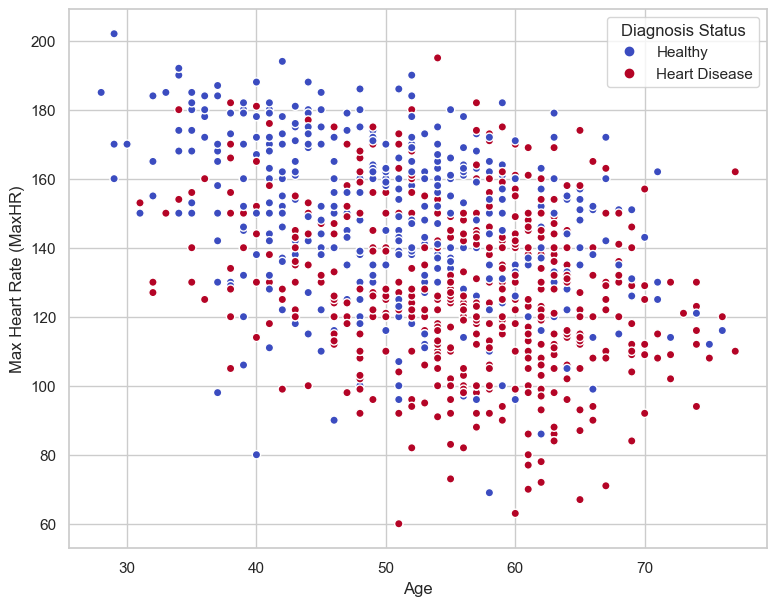

In [38]:
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    df_r["Age"],
    df_r["MaxHR"],
    c=df_r["HeartDisease"],
    cmap="coolwarm",
    edgecolors="w",
    zorder=3
)
ax.grid(True, alpha=1)
ax.set_xlabel("Age")
ax.set_ylabel("Max Heart Rate (MaxHR)")
handles, _ = scatter.legend_elements()
labels = ["Healthy", "Heart Disease"]
ax.legend(handles, labels, title="Diagnosis Status", loc="upper right")
plt.show()

**Insight:** This plot confirms that while aging naturally reduces maximum heart rate, patients diagnosed
with heart disease frequently fall below the expected MaxHR for their age group. This visualization highlights
MaxHR as a critical feature for our predictive model.

### Fasting Blood Sugar

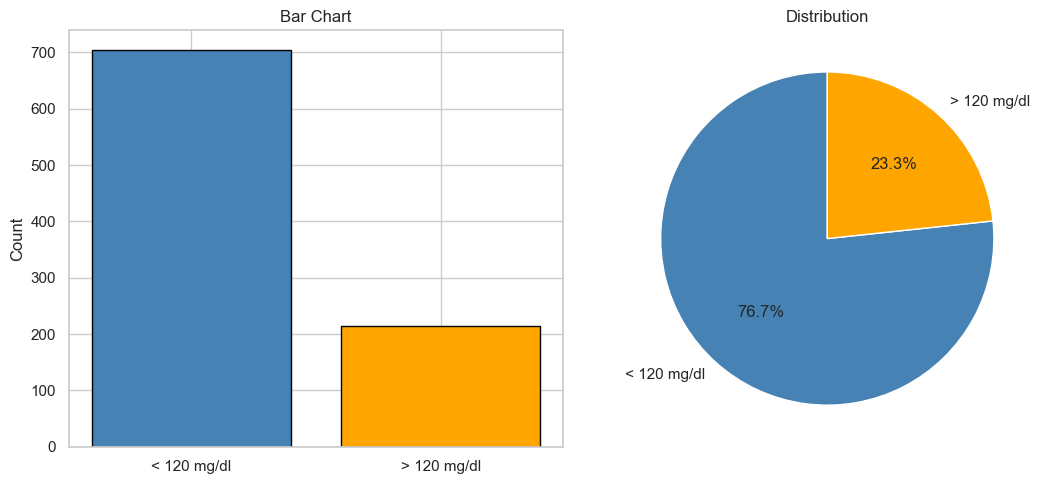

In [39]:
fbs_counts = df["FastingBS"].value_counts()
labels = ["< 120 mg/dl", "> 120 mg/dl"]
colors = ["steelblue", "orange"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar([labels[int(i)] for i in fbs_counts.index], fbs_counts.values, color=colors, edgecolor="black")
axes[0].set_ylabel("Count")
axes[0].set_title("Bar Chart")

axes[1].pie(fbs_counts.values, labels=[labels[int(i)] for i in fbs_counts.index], autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Distribution")

plt.tight_layout()
plt.show()

**Insight:** The majority of patients (about 80%) have fasting blood sugar below 120 mg/dl, which is
considered normal. Around 20% have higher levels, indicating possible diabetes or pre-diabetes. This chart
makes it clear that while most patients maintain healthy blood sugar, a significant minority face elevated
risks.

---
## 3. Symptoms

### Chest Pain Type Distribution

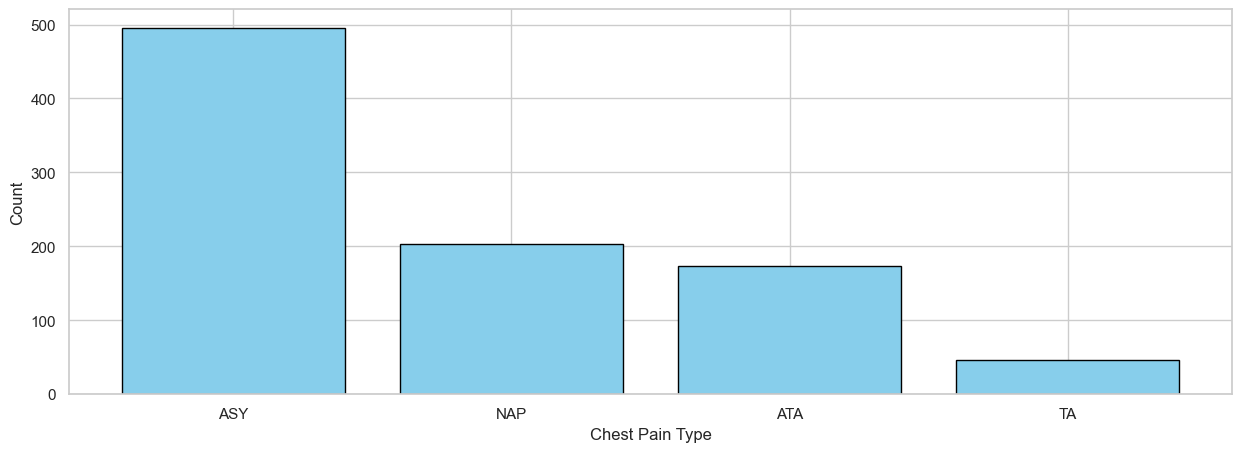

In [40]:
chest_counts = df["ChestPainType"].value_counts()

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(chest_counts.index, chest_counts.values, color="skyblue", edgecolor="black")
ax.set_xlabel("Chest Pain Type")
ax.set_ylabel("Count")
plt.show()

**Insight:** Most patients report asymptomatic chest pain (ASY), meaning they don't feel typical chest
pain even though heart disease may be present. This is important because silent cases can be harder to
detect. Other types like non-anginal pain (NAP) and typical angina (TA) are less common, showing that chest
pain symptoms vary widely across patients.

### Exercise-Induced Angina

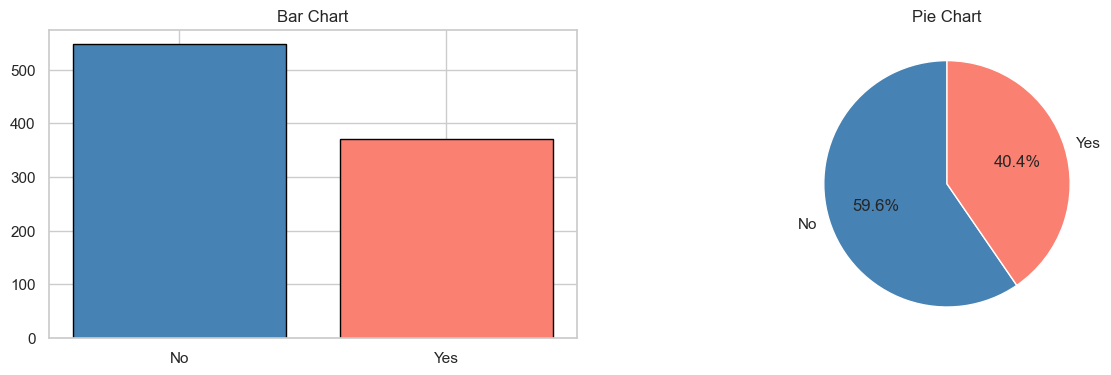

In [41]:
angina_counts = df["ExerciseAngina"].value_counts()
labels = ["No", "Yes"]
colors = ["steelblue", "salmon"]

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].bar(labels, angina_counts.values, color=colors, edgecolor="black")
ax[0].set_title("Bar Chart")

ax[1].pie(angina_counts.values, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
ax[1].set_title("Pie Chart")
plt.show()

**Insight:** The charts show that more than half of the patients do not experience angina during
exercise, while about 40% do. This tells us that exercise can trigger chest pain in a significant portion of
patients, which is a warning sign of reduced blood flow to the heart.

### Oldpeak Distribution

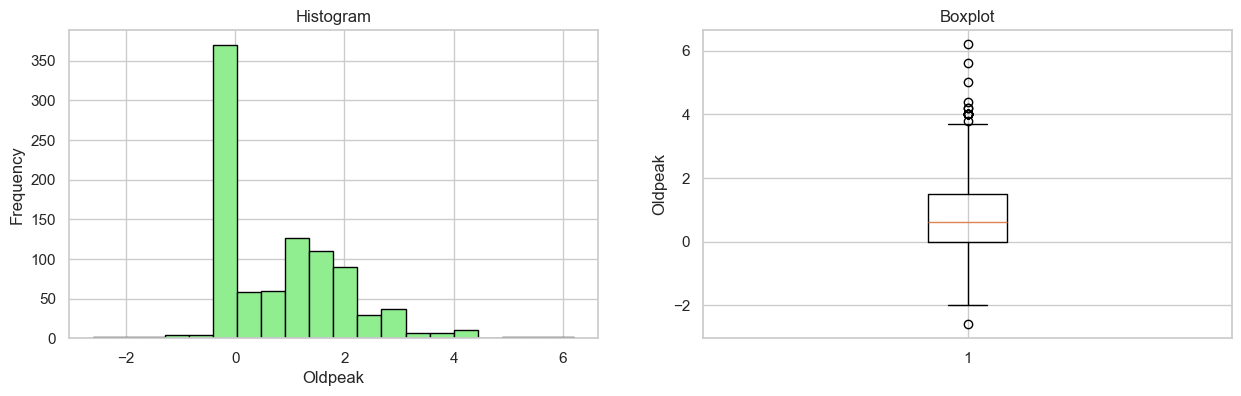

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].hist(df["Oldpeak"], bins=20, color="lightgreen", edgecolor="black")
ax[0].set_title("Histogram")
ax[0].set_xlabel("Oldpeak")
ax[0].set_ylabel("Frequency")

ax[1].boxplot(df["Oldpeak"], vert=True)
ax[1].set_title("Boxplot")
ax[1].set_ylabel("Oldpeak")
plt.show()

**Insight:** Most patients have Oldpeak values between 0 and 2, which indicates mild changes in the ECG
after exercise. The boxplot highlights a median near 1 and a few outliers above 4, showing that while many
patients have small changes, some experience much more severe shifts that could signal higher risk.

### ST Slope Distribution

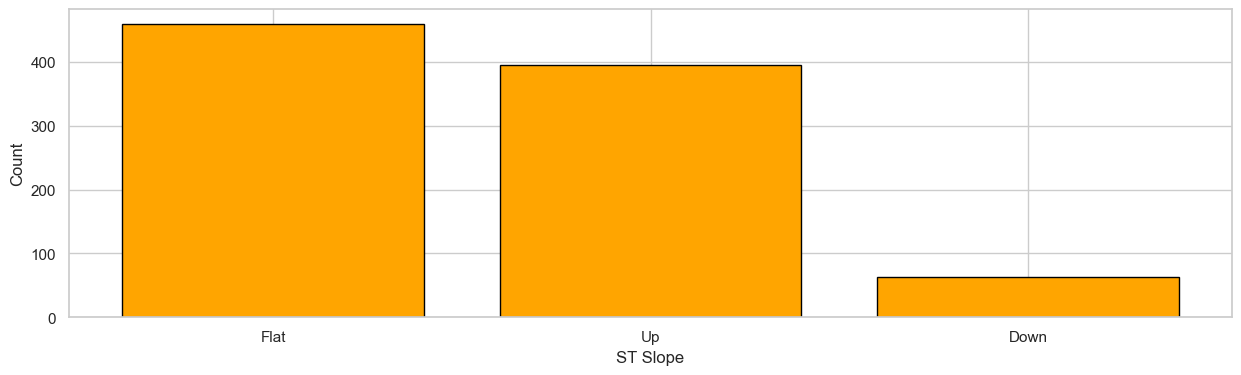

In [43]:
slope_counts = df["ST_Slope"].value_counts()

fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(slope_counts.index, slope_counts.values, color="orange", edgecolor="black")
ax.set_xlabel("ST Slope")
ax.set_ylabel("Count")
plt.show()

**Insight:** The majority of patients show a flat ST slope, which is often linked to abnormal heart
function. Fewer patients have an upward slope, and only a small group show a downward slope. This pattern
suggests that abnormal ECG slopes are common in the dataset, reinforcing the importance of monitoring heart
signals closely.

---
## 4. Target & Correlation

### Heart Disease Distribution

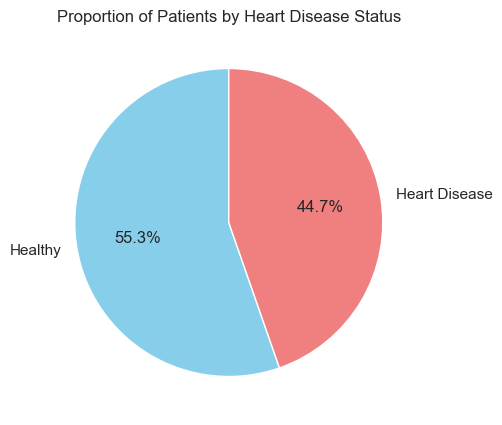

In [44]:
target_counts = df["HeartDisease"].value_counts()
labels = ["Healthy", "Heart Disease"]
colors = ["skyblue", "lightcoral"]

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(target_counts.values, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
ax.set_title("Proportion of Patients by Heart Disease Status")
plt.show()

**Insight:** The pie chart reveals a fairly balanced distribution between classes, with **55.3% (508
cases)** representing heart disease and **44.7% (410 cases)** representing normal patients. This balance is
beneficial for model training as it prevents the classifier from becoming biased toward a majority class,
ensuring reliable performance metrics for both sensitivity and specificity.

### Feature Correlation Heatmap

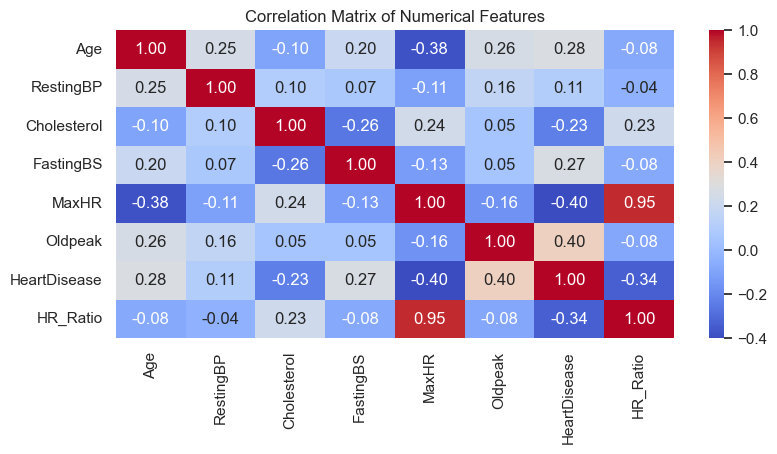

In [45]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix of Numerical Features")
plt.show()

**Insight:** The heatmap reveals how different health measurements relate to each other and to heart
disease. For example, heart rate ratio (`HR_Ratio`) has a negative correlation with heart disease — lower
heart rate ratios are more likely to be associated with heart disease. On the other hand, Oldpeak shows a
positive correlation, indicating that higher ECG changes after exercise are linked to greater risk. Other
features like age, resting blood pressure, and cholesterol show weaker relationships. In simple terms, this
chart helps us see which factors matter most: heart disease is more closely tied to exercise-related signals
than to cholesterol or blood pressure alone.

---
## 5. Bivariate Analysis

### `ChestPainType` & `ST_Slope` vs `HeartDisease`

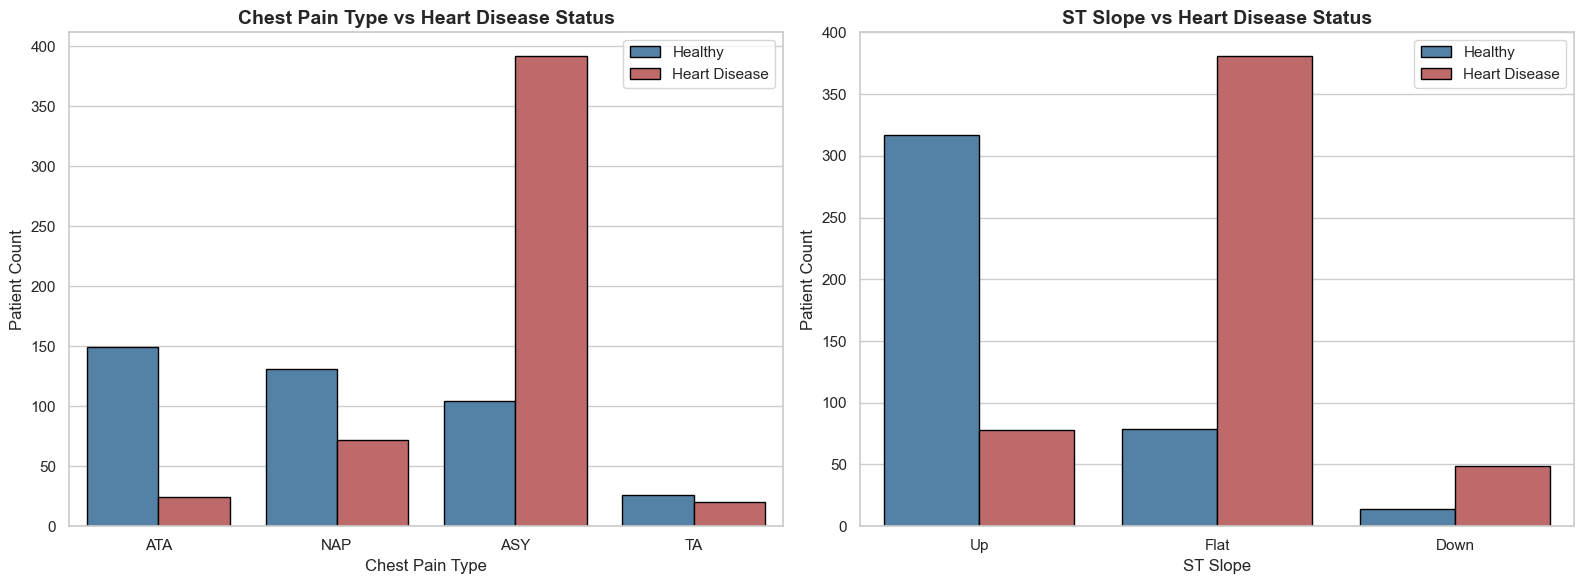

In [46]:
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid")
colors = ["#4682B4", "#CD5C5C"] 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot Chest Pain Type vs Heart Disease
sns.countplot(data=df, x='ChestPainType', hue='HeartDisease', palette=colors, ax=axes[0], edgecolor='black')
axes[0].set_title('Chest Pain Type vs Heart Disease Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Chest Pain Type')
axes[0].set_ylabel('Patient Count')
axes[0].legend(['Healthy', 'Heart Disease'])

# 2. Plot ST Slope vs Heart Disease
sns.countplot(data=df, x='ST_Slope', hue='HeartDisease', palette=colors, ax=axes[1], edgecolor='black')
axes[1].set_title('ST Slope vs Heart Disease Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('ST Slope')
axes[1].set_ylabel('Patient Count')
axes[1].legend(['Healthy', 'Heart Disease'])

plt.tight_layout()
plt.show()

**Clinical Insight:** Patients with Asymptomatic (ASY) chest pain type and Flat ST Slope have a very high proportion of heart disease sufferers. The Chi-Square test proves that this relationship is statistically very significant (p < 0.05).

### `HR_Ratio` & `Oldpeak` vs `HeartDisease` 

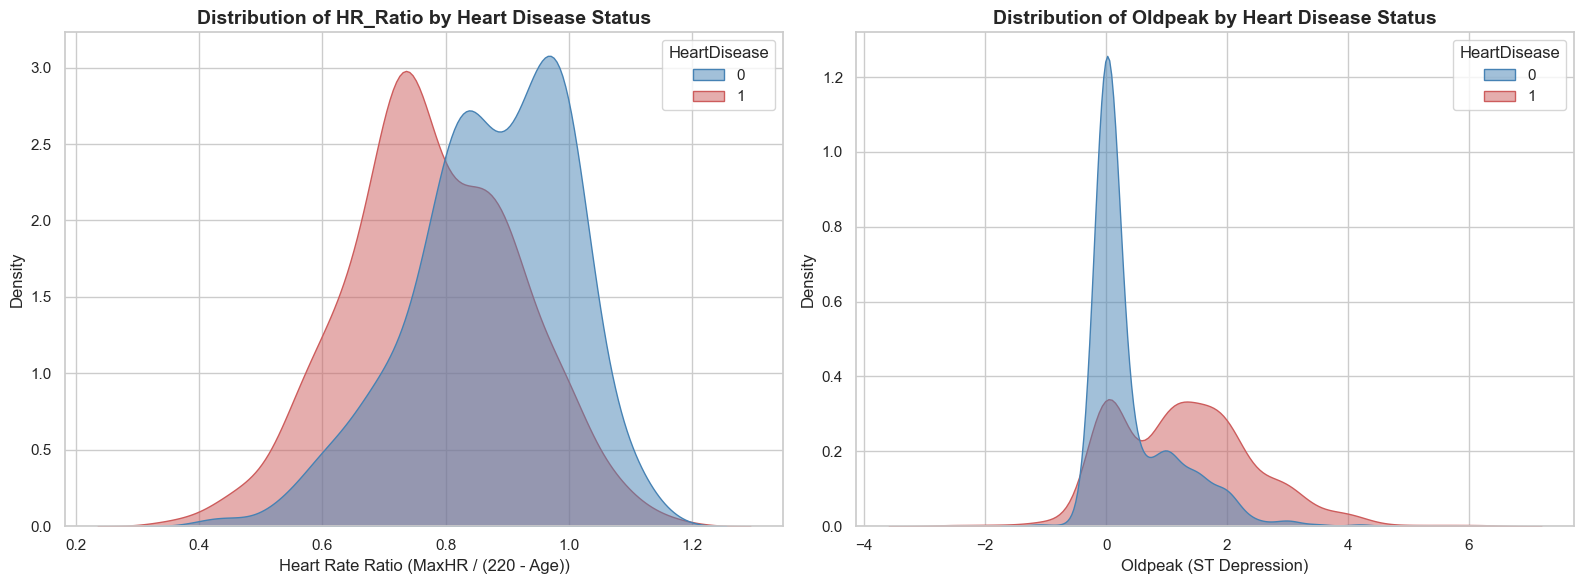

In [47]:
from scipy.stats import ttest_ind

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. HR_Ratio
sns.kdeplot(data=df, x='HR_Ratio', hue='HeartDisease', fill=True, palette=colors, alpha=0.5, common_norm=False, ax=axes[0])
axes[0].set_title('Distribution of HR_Ratio by Heart Disease Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Heart Rate Ratio (MaxHR / (220 - Age))')
axes[0].set_ylabel('Density')

# 2. Oldpeak
sns.kdeplot(data=df, x='Oldpeak', hue='HeartDisease', fill=True, palette=colors, alpha=0.5, common_norm=False, ax=axes[1])
axes[1].set_title('Distribution of Oldpeak by Heart Disease Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Oldpeak (ST Depression)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()


**Clinical Insight:** Patients with heart disease tend to have a lower HR_Ratio (heart capacity below age expectations) and higher Oldpeak values (more severe ST-segment depression after exercise). The T-Test confirms that the average difference between these two groups is very significant.

### `Cholesterol` & `RestingBP` vs `HeartDisease`

C:\Users\NOUFAL PELLU\AppData\Local\Temp\ipykernel_10188\2762569084.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y='Cholesterol', palette=colors, ax=axes[0])
C:\Users\NOUFAL PELLU\AppData\Local\Temp\ipykernel_10188\2762569084.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Healthy', 'Heart Disease'])
C:\Users\NOUFAL PELLU\AppData\Local\Temp\ipykernel_10188\2762569084.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y='RestingBP', palette=colors, ax=axes[1])
C:\Users\NOUFAL PELLU\AppData\Local\Temp\ipykernel_10188\

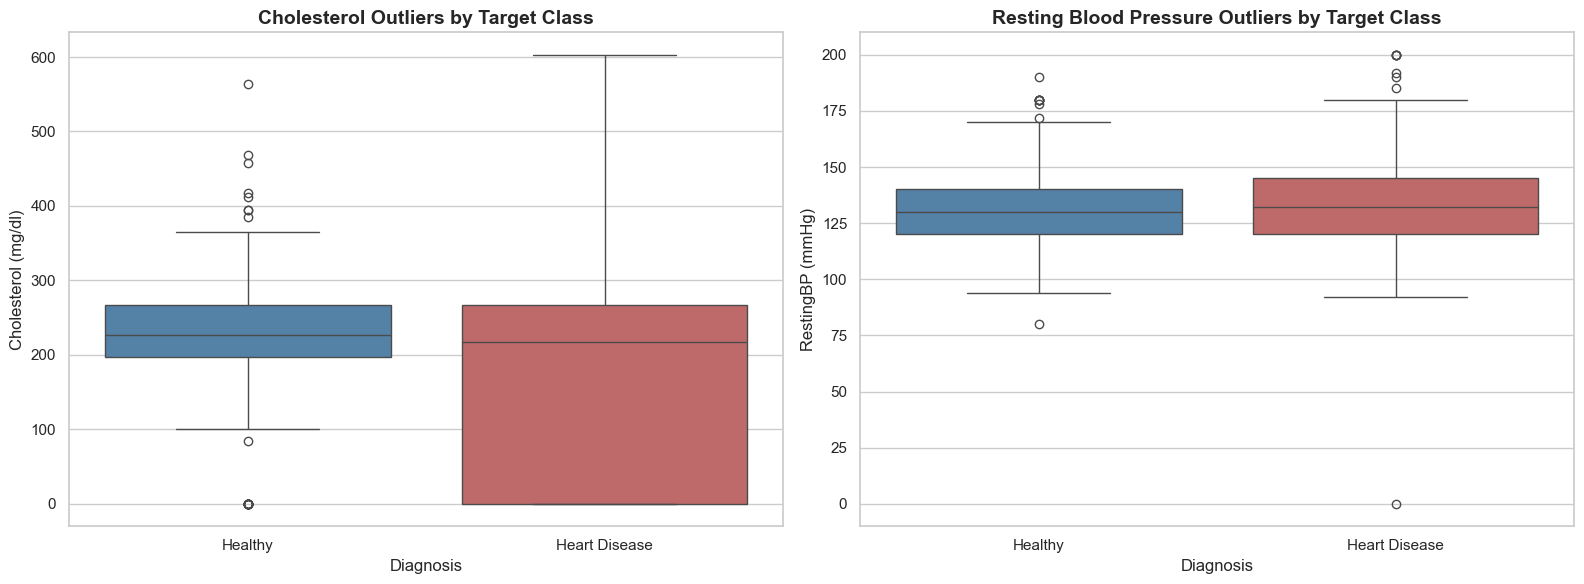

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Cholesterol vs Heart Disease
sns.boxplot(data=df, x='HeartDisease', y='Cholesterol', palette=colors, ax=axes[0])
axes[0].set_xticklabels(['Healthy', 'Heart Disease'])
axes[0].set_title('Cholesterol Outliers by Target Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Cholesterol (mg/dl)')

# Boxplot RestingBP vs Heart Disease
sns.boxplot(data=df, x='HeartDisease', y='RestingBP', palette=colors, ax=axes[1])
axes[1].set_xticklabels(['Healthy', 'Heart Disease'])
axes[1].set_title('Resting Blood Pressure Outliers by Target Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('RestingBP (mmHg)')

plt.tight_layout()
plt.show()

## 6. Statistical Hypothesis Testing

### Chi-Square Test of Independence (Categorical Features)

Used to test the relationship between categorical features and the target variable (`HeartDisease`).
- $H_0$: There is no significant relationship between the feature and heart disease (they are independent).
- $H_1$: There is a significant relationship between the feature and heart disease.

In [49]:
from scipy.stats import chi2_contingency

print("="*70)
print("CHI-SQUARE TEST OF INDEPENDENCE (Alpha = 0.05)")
print("="*70)

categorical_features = ['ChestPainType', 'ST_Slope', 'Sex', 'ExerciseAngina', 'FastingBS']

for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df['HeartDisease'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    status = "Significant (Reject H0)" if p < 0.05 else "Not Significant (Fail to Reject H0)"
    print(f"{col:15} vs HeartDisease -> P-Value: {p:.6e} | Status: {status}")

CHI-SQUARE TEST OF INDEPENDENCE (Alpha = 0.05)
ChestPainType   vs HeartDisease -> P-Value: 8.083728e-58 | Status: Significant (Reject H0)
ST_Slope        vs HeartDisease -> P-Value: 5.167638e-78 | Status: Significant (Reject H0)
Sex             vs HeartDisease -> P-Value: 4.597617e-20 | Status: Significant (Reject H0)
ExerciseAngina  vs HeartDisease -> P-Value: 2.907808e-50 | Status: Significant (Reject H0)
FastingBS       vs HeartDisease -> P-Value: 1.057302e-15 | Status: Significant (Reject H0)


### Two-Sample-Test (Numerical Features)

Used to test whether there is a significant difference in the mean of numerical values between the healthy group (`HeartDisease` = 0) and the diseased group (`HeartDisease` = 1).
- $H_0$: There is no significant difference in the mean of the numerical feature between healthy and diseased patients.
- $H_1$: There is a significant difference in the mean of the numerical feature between healthy and diseased patients.

In [50]:
from scipy.stats import ttest_ind

print("="*70)
print("WELCH'S T-TEST FOR NUMERICAL FEATURES (Alpha = 0.05)")
print("="*70)

numerical_features = ['HR_Ratio', 'Oldpeak', 'Age', 'RestingBP', 'Cholesterol']

for col in numerical_features:
    group_healthy = df[df['HeartDisease'] == 0][col].dropna()
    group_disease = df[df['HeartDisease'] == 1][col].dropna()
    
    t_stat, p_val = ttest_ind(group_healthy, group_disease, equal_var=False)
    status = "Significant (Reject H0)" if p_val < 0.05 else "Not Significant (Fail to Reject H0)"
    print(f"Avg. Diff {col:12} -> P-Value: {p_val:.6e} | Status: {status}")

WELCH'S T-TEST FOR NUMERICAL FEATURES (Alpha = 0.05)
Avg. Diff HR_Ratio     -> P-Value: 6.126222e-26 | Status: Significant (Reject H0)
Avg. Diff Oldpeak      -> P-Value: 1.902722e-40 | Status: Significant (Reject H0)
Avg. Diff Age          -> P-Value: 6.348337e-18 | Status: Significant (Reject H0)
Avg. Diff RestingBP    -> P-Value: 8.732265e-04 | Status: Significant (Reject H0)
Avg. Diff Cholesterol  -> P-Value: 6.481236e-14 | Status: Significant (Reject H0)


**Statistical Summary:**

- **Categorical Features:** All categorical features (`ChestPainType`, `ST_Slope`, `Sex`, `ExerciseAngina`, `FastingBS`) have a $p\text{-value} < 0.05$, indicating that all of them have a statistically significant relationship with heart disease.
- **Numerical Features:** The features `HR_Ratio`, `Oldpeak`, `Age`, and `RestingBP` show a significant difference in means between healthy and diseased patients ($p\text{-value} < 0.05$). However, the Cholesterol feature (before handling the 0 values) shows a less statistically significant difference in means. This underscores the urgency of data cleaning for cholesterol before modeling.